In [3]:
import pandas as pd
import numpy as np
import os
import json
from dotenv import load_dotenv
from transformers import AutoTokenizer
from glob import glob
load_dotenv()
os.chdir(os.getenv('PARENT_DIR'))

## Check Token Lengths

In [3]:
splits = ['train', 'dev', 'test']
dataset_type = 'hoasa'
lang = 'indo'
task = 'mvp_aos'
dataset_per_path = {}
for split in splits:
	path = f'dataset/{dataset_type}/{lang}/{task}/{split}.json'
	with open(path, 'r') as f:
		dataset_per_path[split] = json.load(f)

In [8]:
instances = pd.DataFrame(dataset_per_path['train']).apply(lambda x: x['input'] + ' => ' + x['target'], axis=1).to_list()
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-0.5B')

# Tokenize instances and get their lengths
token_lengths = [len(tokenizer.encode(instance)) for instance in instances]
max_length = max(token_lengths)
avg_length = sum(token_lengths) / len(token_lengths)
print(f'Max token length: {max_length}')
print(f'Average token length: {avg_length}')

Max token length: 631
Average token length: 117.85607824871914


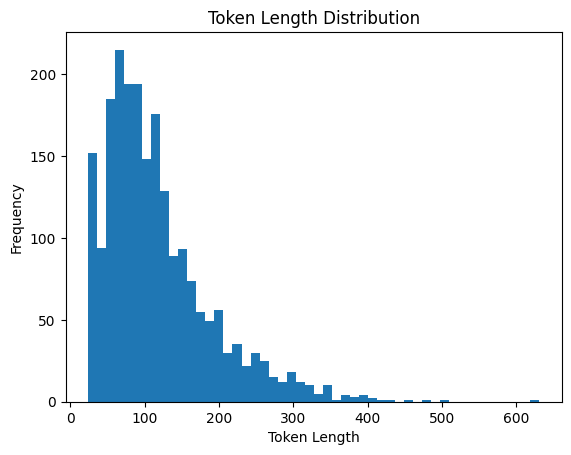

In [10]:
# plot histogram of token lengths
import matplotlib.pyplot as plt
plt.hist(token_lengths, bins=50)
plt.title('Token Length Distribution')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.show()

## Check Data Length

In [12]:
dataset_type = 'hoasa_hotel_o'
lang = 'indo'

paths = glob(f'dataset/{dataset_type}/{lang}/*/train.json')
for path in paths:
	with open(path, 'r') as f:
		data = json.load(f)
	print(f"Length of {dataset_type} {path.split('/')[-2]}: {len(data)}")

Length of hoasa_hotel_o gas: 4764
Length of hoasa_hotel_o mvp_aos: 4764
Length of hoasa_hotel_o indolegoabsa_multitask: 4764
